# Import

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# because i need to import this nlng rather than pyfim huhuhu
try:
    import pyfpgrowth
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyfpgrowth"])
    import pyfpgrowth

from mlxtend.frequent_patterns import apriori

from sklearn.preprocessing import MultiLabelBinarizer
from collections import defaultdict
import itertools


# Load Data

In [2]:
#folder_path = "/mnt/data/public/food-com-recipes/RAW_recipes.csv"
folder_path = "data/RAW_recipes.csv"
df = pd.read_csv(folder_path)

In [3]:
df.shape

(231637, 12)

# Data Preprocessing

We wont remove any of the null values since the relevant columns (tags, nutrition, and ingredients) are complete. Even if there are many nulls in description, that just means that the customer chose to not provide descriptive feedback. This should not affect our analysis.

In [4]:
df.isnull().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

In [ ]:
# Convert the tags into a list
df["nutrition"] = df["nutrition"].apply(json.loads)

# Convert the tags into
df['tags'] = df['tags'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)
df['ingredients'] = df['ingredients'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)

# EDA

Hi bingbong insert EDA here please based on the plan

# Results and Discussion

## FIM all ingredients for both healthy food and every food


### Hyperparameter tuning

count    13426.000000
mean         0.002283
std          0.005127
min          0.001002
25%          0.001179
50%          0.001455
75%          0.002102
max          0.370174
Name: support, dtype: float64


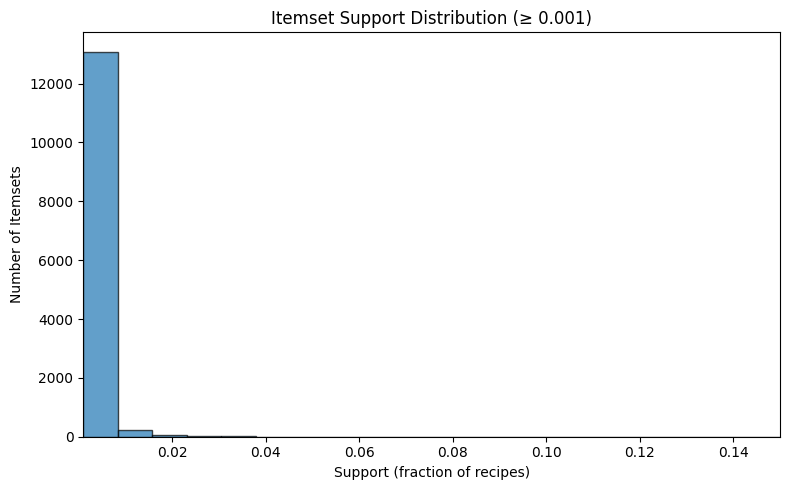

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pyfpgrowth

# --- Prepare transactions (list of ingredient lists) ---
transactions = df['ingredients'].tolist()

# --- Set minimum support threshold ---
min_support = 0.001  # you can adjust this

# --- Compute absolute minimum support count ---
minsup_count = max(1, int(len(transactions) * min_support))

# --- Find frequent itemsets ---
patterns = pyfpgrowth.find_frequent_patterns(transactions, 
                                             minsup_count)

# --- Convert to DataFrame ---
itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
itemset_freq['support'] = itemset_freq['count'] / len(df)

# --- Filter supports (just to zoom in) ---
itemset_freq = itemset_freq[itemset_freq['support'] >= 0.001]

# --- Show summary statistics ---
print(itemset_freq['support'].describe())

# --- Plot histogram ---
plt.figure(figsize=(8, 5))
plt.hist(itemset_freq['support'], bins=50, edgecolor='black', 
         alpha=0.7)
plt.title("Itemset Support Distribution (≥ 0.001)")
plt.xlabel("Support (fraction of recipes)")
plt.ylabel("Number of Itemsets")

# --- Adjust x-axis and layout ---
plt.xlim(0.001, 0.15)
plt.margins(x=0.02, y=0.05)
plt.tight_layout()
plt.show()


count    48.000000
mean      0.642372
std       0.111926
min       0.502166
25%       0.534113
50%       0.611417
75%       0.767222
max       0.835999
dtype: float64


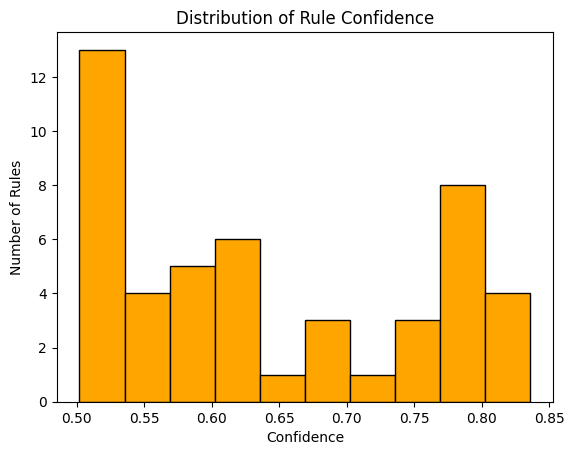

In [ ]:
import pyfpgrowth

# Choose support threshold based on percentile 
min_support = 0.015

# Use your data-driven min_support
minsup_count = max(1, int(len(df) * min_support))
freq_items = pyfpgrowth.find_frequent_patterns(df['ingredients'].to_list(), 
minsup_count)

# Generate rules with a low min_conf to inspect distribution
rules = pyfpgrowth.generate_association_rules(freq_items, 0.5)

# Collect all confidence values
confidences = [conf for (_, (__, conf)) in rules.items()]

# Display stats and histogram
print(pd.Series(confidences).describe())

plt.hist(confidences, bins=10, color='orange', edgecolor = 'black')
plt.title("Distribution of Rule Confidence")
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.show()


### Using best parameters

we chose minsupport = 0.01 using elbow method and will use min confidence = 0.79 since it captures the top quartile of high-quality rules for a strong rule zone

In [ ]:
import pyfpgrowth
import pandas as pd

# --- Parameters ---
min_support = 0.015
min_confidence = 0.55

# --- Step 1: Compute minsup count ---
num_transactions = len(df['ingredients'])
minsup_count = max(1, int(num_transactions * min_support))

# --- Step 2: Find frequent itemsets ---
freq_itemsets = pyfpgrowth.find_frequent_patterns(df['ingredients'].to_list(),
                                                  minsup_count)

# --- Step 3: Generate association rules ---
rules = pyfpgrowth.generate_association_rules(freq_itemsets, min_confidence)

# --- Step 4: Add support & lift for each rule ---
def get_support(itemset):
    """Return support of an itemset."""
    return freq_itemsets.get(itemset, 0) / num_transactions

lifted_rules = []
for antecedent, (consequent, confidence) in rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)
    if consequent_support == 0:
        continue
    lift = confidence / consequent_support
    lifted_rules.append((antecedent, consequent, confidence, lift))

# --- Step 5: Sort rules by confidence (and optionally lift) ---
lifted_rules = sorted(lifted_rules, key=lambda x: (x[2], x[3]), reverse=True)

# --- Step 6: Display top 10 rules ---
top10_rules = lifted_rules[:10]
for i, (antecedent, consequent, confidence, lift) in enumerate(top10_rules, 
                                                               start=1):
    print(f"{i}. {set(antecedent)} -> {set(consequent)} "
          f"(confidence = {confidence:.2f}, lift = {lift:.2f})")


1. {'butter', 'pepper'} -> {'salt'} (confidence = 0.84, lift = 2.26)
2. {'all-purpose flour', 'baking soda'} -> {'salt'} (confidence = 0.81, lift = 2.20)
3. {'olive oil', 'pepper'} -> {'salt'} (confidence = 0.81, lift = 2.20)
4. {'onion', 'pepper'} -> {'salt'} (confidence = 0.81, lift = 2.20)
5. {'all-purpose flour', 'baking powder'} -> {'salt'} (confidence = 0.80, lift = 2.17)
6. {'baking powder', 'milk'} -> {'salt'} (confidence = 0.80, lift = 2.16)
7. {'vanilla', 'baking soda'} -> {'salt'} (confidence = 0.79, lift = 2.13)
8. {'sugar', 'baking soda'} -> {'salt'} (confidence = 0.79, lift = 2.13)
9. {'eggs', 'sugar', 'baking powder'} -> {'salt'} (confidence = 0.78, lift = 2.11)
10. {'sugar', 'baking powder'} -> {'salt'} (confidence = 0.78, lift = 2.10)


## FIM all ingredients for healthy food filtered by tags


### Get Healthy Recipes

We classified a recipe to be healthy if it has the tags 'healthy' or 'healthy-2'.

In [ ]:
# Create a tags presence matrix
mlb = MultiLabelBinarizer()
tags_matrix = mlb.fit_transform(df['tags'])
df_tags_matrix = pd.DataFrame(tags_matrix, columns=mlb.classes_, 
                              index=df.index)

# Get the healthy foods based on the tags
is_healthy_tag = df_tags_matrix['healthy'] == 1
is_healthy_2_tag = df_tags_matrix['healthy-2'] == 1
is_health_tag = is_healthy_tag | is_healthy_2_tag
is_healthy_food = df_tags_matrix[is_health_tag].index

df_healthy = df.loc[is_healthy_food]

# Save the csv
pd.Series(is_healthy_food).to_csv('data/is_healthy_food.csv', 
                                  index=False, header=False)

In [10]:
df_healthy.to_json('data/healthy_foods.json', orient='records')

### Hyperparameter tune

count    389.000000
mean       0.019656
std        0.024494
min        0.010025
25%        0.011707
50%        0.014849
75%        0.019541
max        0.389749
Name: support, dtype: float64


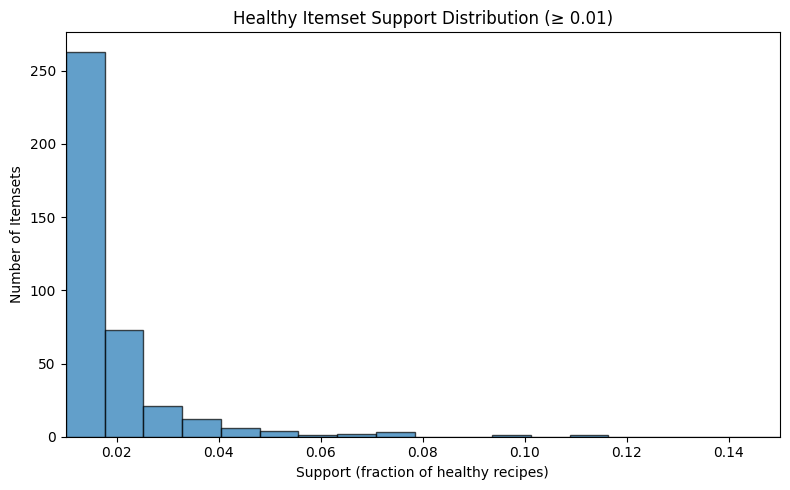

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pyfpgrowth

# --- Prepare transactions (list of ingredient lists) ---
transactions = df_healthy['ingredients'].tolist()

# --- Set minimum support threshold ---
min_support = 0.01  # you can adjust this

# --- Compute absolute minimum support count ---
minsup_count = max(1, int(len(transactions) * min_support))

# --- Find frequent itemsets ---
patterns = pyfpgrowth.find_frequent_patterns(transactions, 
                                             minsup_count)

# --- Convert to DataFrame ---
itemset_freq = pd.DataFrame({
    'itemset': list(patterns.keys()),
    'count': list(patterns.values())
})
itemset_freq['support'] = itemset_freq['count'] / len(df_healthy)

# --- Filter supports (just to zoom in) ---
itemset_freq = itemset_freq[itemset_freq['support'] >= 0.01]

# --- Show summary statistics ---
print(itemset_freq['support'].describe())

# --- Plot histogram ---
plt.figure(figsize=(8, 5))
plt.hist(itemset_freq['support'], bins=50, edgecolor='black', alpha=0.7)
plt.title("Healthy Itemset Support Distribution")
plt.xlabel("Support (fraction of healthy recipes)")
plt.ylabel("Number of Itemsets")

# --- Adjust x-axis and layout ---
plt.xlim(0.01, 0.15)
plt.margins(x=0.02, y=0.05)
plt.tight_layout()
plt.show()


count    24.000000
mean      0.649468
std       0.110352
min       0.500541
25%       0.551172
50%       0.655113
75%       0.763814
max       0.815074
dtype: float64


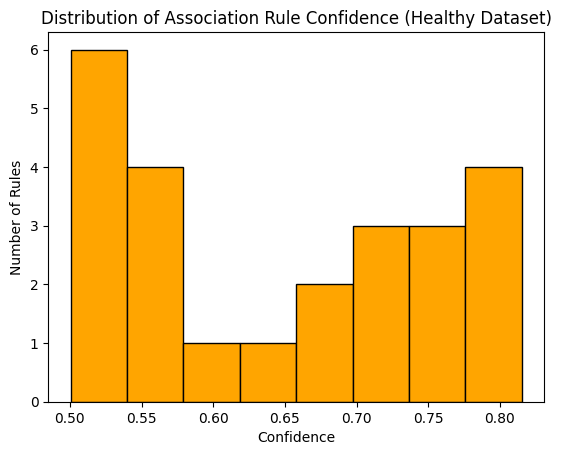

In [ ]:
import pyfpgrowth
import pandas as pd
import matplotlib.pyplot as plt

# --- Use the tuned or chosen min_support from Step 1 ---
min_support = 0.02  

# --- Compute minimum support count ---
minsup_count = max(1, int(len(df_healthy) * min_support))

# --- Mine frequent itemsets for healthy recipes ---
healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(), minsup_count
)

# --- Generate association rules with a LOW confidence threshold ---
# We start low (e.g., 0.5) to capture the full confidence distribution
healthy_rules=pyfpgrowth.generate_association_rules(healthy_freq_ingredients,
                                                      0.5)

# --- Extract all confidence values ---
confidences = [conf for (_, (__, conf)) in healthy_rules.items()]

# --- Show descriptive statistics of confidence distribution ---
print(pd.Series(confidences).describe())

# --- Plot histogram of confidence values ---
plt.hist(confidences, bins=8, color='orange', edgecolor='black')
plt.title("Distribution of Association Rule Confidence (Healthy Dataset)")
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.show()


### Using Best Parameters

#### Check

In [ ]:
import pyfpgrowth
import pandas as pd

# --- Set tuned hyperparameters ---
min_support = 0.02
min_confidence = 0.6

# --- Compute minimum support count ---
minsup_count = max(1, int(len(df_healthy) * min_support))

# --- Mine frequent itemsets ---
healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df_healthy['ingredients'].to_list(),
    minsup_count
)

# --- Generate association rules ---
healthy_rules = pyfpgrowth.generate_association_rules(
    healthy_freq_ingredients,
    min_confidence
)

# --- Calculate support for each itemset ---
def get_support(itemset):
    """Return support (fraction of transactions)."""
    return healthy_freq_ingredients.get(itemset, 0) / len(df_healthy)


# --- Compute lift for each rule ---
lifted_rules = []
for antecedent, (consequent, confidence) in healthy_rules.items():
    antecedent_support = get_support(antecedent)
    consequent_support = get_support(consequent)

    # Avoid divide-by-zero errors
    if consequent_support == 0:
        continue

    lift = confidence / consequent_support
    lifted_rules.append(
        (antecedent, consequent, confidence, lift)
    )

# --- Sort rules by confidence (and lift) descending ---
lifted_rules = sorted(
    lifted_rules,
    key=lambda x: (x[2], x[3]),
    reverse=True
)

# --- Get Top 10 rules ---
top10_rules_lift = lifted_rules[:10]

# --- Display neatly ---
print("Top 10 Association Rules (min_support=0.02, min_confidence=0.6)\n")

for i, (antecedent, consequent, confidence, lift) in enumerate(
    top10_rules_lift, start=1
):
    print(
        f"{i}. {set(antecedent)} -> {set(consequent)} "
        f"(confidence = {confidence:.2f}, lift = {lift:.2f})"
    )


Top 10 Association Rules (min_support=0.02, min_confidence=0.6)

1. {'sugar', 'all-purpose flour'} -> {'salt'} (confidence = 0.82, lift = 2.09)
2. {'all-purpose flour', 'baking powder'} -> {'salt'} (confidence = 0.81, lift = 2.09)
3. {'sugar', 'baking powder'} -> {'salt'} (confidence = 0.79, lift = 2.01)
4. {'sugar', 'baking soda'} -> {'salt'} (confidence = 0.78, lift = 1.99)
5. {'flour', 'baking powder'} -> {'salt'} (confidence = 0.77, lift = 1.98)
6. {'flour', 'sugar'} -> {'salt'} (confidence = 0.76, lift = 1.96)
7. {'baking powder', 'baking soda'} -> {'salt'} (confidence = 0.76, lift = 1.96)
8. {'eggs', 'sugar'} -> {'salt'} (confidence = 0.72, lift = 1.85)
9. {'butter', 'flour'} -> {'salt'} (confidence = 0.71, lift = 1.82)
10. {'butter', 'sugar'} -> {'salt'} (confidence = 0.71, lift = 1.82)


### Compare if the frequent ingredients in all and healthy-only recipes are similar

We use the Jaccard index as a way to measure similarity. Since the similarity is 0.52 between the frequent ingredient itemsets of all recipes and healthy-only recipes, this indicates that there is only a moderate overlap between the two groups. In other words, nearly half of the commonly used ingredients in healthy recipes are not the same as those in the general recipe population. This suggests that healthy recipes rely on a distinct set of ingredients, reflecting meaningful differences in ingredient composition and dietary choices.

In [ ]:
num_recipes = len(df['ingredients'])
min_support_pct = 0.015
minsup_count = max(1, int(num_recipes * min_support_pct))

all_freq_ingredients = pyfpgrowth.find_frequent_patterns(
    df['ingredients'].to_list(),
    minsup_count
)


def jaccard_index(list1, list2):
    """Compute the Jaccard index between two lists."""
    set1 = set(list1)
    set2 = set(list2)

    # Avoid division by zero when both lists are empty
    if not set1 and not set2:
        return 0

    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return intersection / union


jaccard_index(
    list(all_freq_ingredients.keys()),
    list(healthy_freq_ingredients.keys())
)


0.42066420664206644

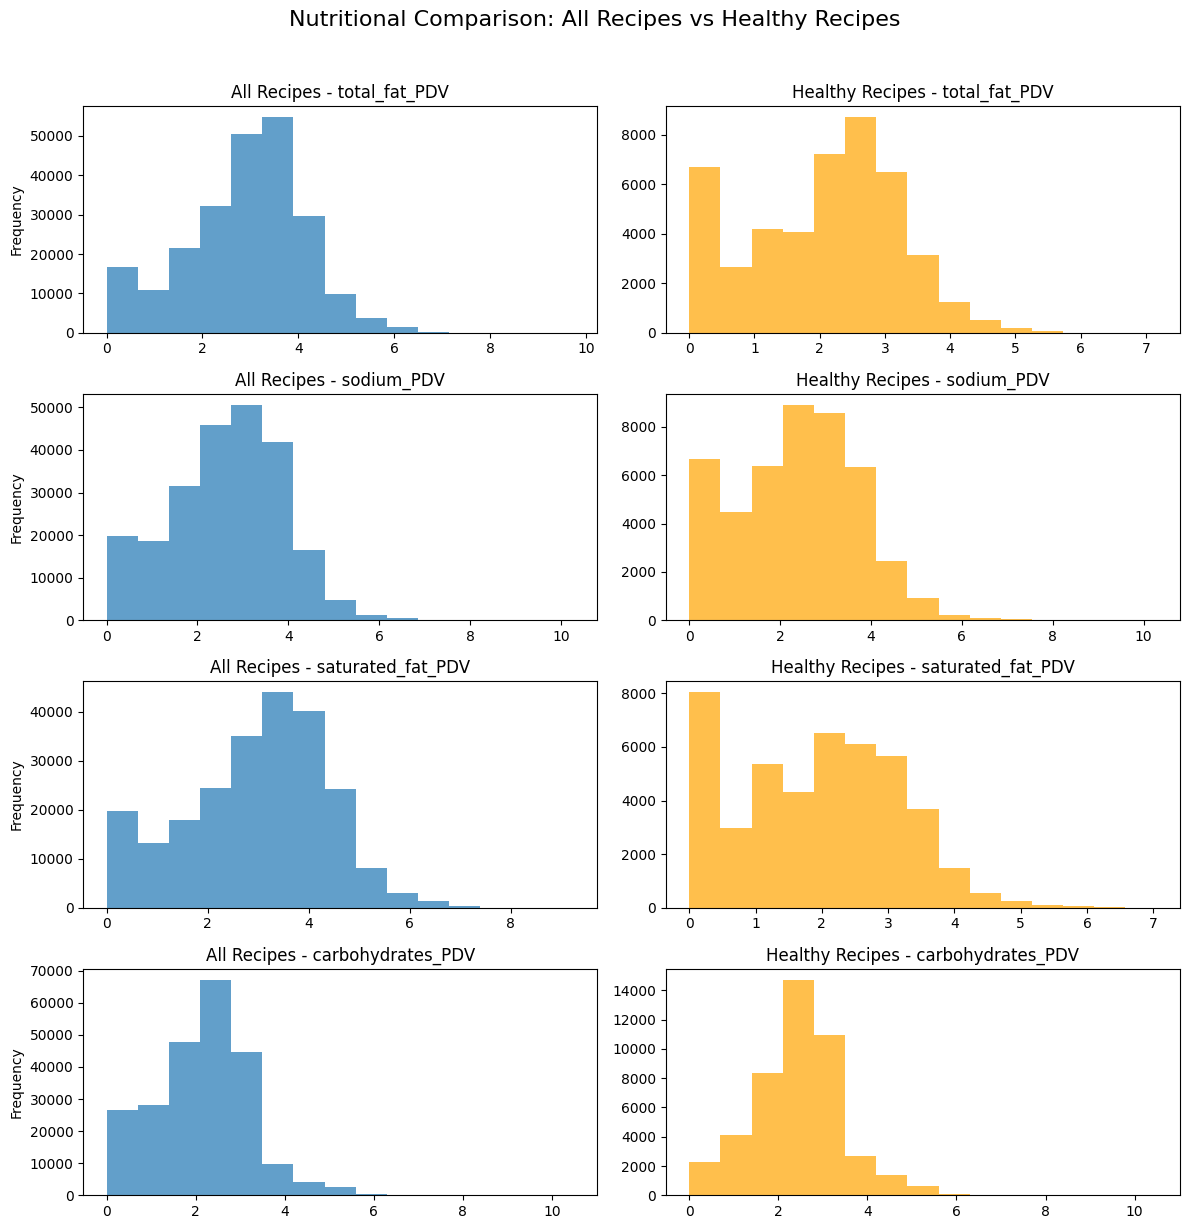

In [ ]:
nutrition_cols = [
    "calories",
    "total_fat_PDV",
    "sugar_PDV",
    "sodium_PDV",
    "protein_PDV",
    "saturated_fat_PDV",
    "carbohydrates_PDV",
]

df_all_nutritions = df["nutrition"].apply(pd.Series)
df_all_nutritions.columns = nutrition_cols

df_healthy_nutritions = df_healthy["nutrition"].apply(pd.Series)
df_healthy_nutritions.columns = nutrition_cols

# Select only the 4 columns to visualize
selected_cols = [
    "total_fat_PDV",
    "sodium_PDV",
    "saturated_fat_PDV",
    "carbohydrates_PDV",
]

fig, axes = plt.subplots(
    nrows=len(selected_cols),
    ncols=2,
    figsize=(12, 12)
)
fig.suptitle(
    "Nutritional Comparison: All Recipes vs Healthy Recipes",
    fontsize=16,
    y=1.02
)

for i, col in enumerate(selected_cols):
    axes[i, 0].hist(
        np.log1p(df_all_nutritions[col].dropna()),
        bins=15,
        alpha=0.7
    )
    axes[i, 0].set_title(f"All Recipes - {col}")
    axes[i, 0].set_ylabel("Frequency")

    axes[i, 1].hist(
        np.log1p(df_healthy_nutritions[col].dropna()),
        bins=15,
        alpha=0.7,
        color="orange"
    )
    axes[i, 1].set_title(f"Healthy Recipes - {col}")

plt.tight_layout()
plt.show()


We also check the differences in the distribution of the nutritional values between all the recipes and just the healthy recipes. We see that most of them are similar, except for total_fat_PDV and saturated_fat_PDV. THis makes sense because like...yeahh....

### Robustness

In [ ]:
def test_itemset_robustness_pyfpgrowth(
    transactions,
    min_support_ratio=0.04,
    n_shuffles=5,
    random_state=42
):
    """
    Test robustness of frequent itemsets to shuffling using pyfpgrowth.

    Args:
        transactions (list of lists): e.g. [['milk', 'bread'], ['beer', ...]]
        min_support_ratio (float): Fraction of total transactions for min_support.
        n_shuffles (int): Number of shuffle iterations.
        random_state (int): Base seed for reproducibility.

    Returns:
        pd.DataFrame: Overlap ratios across runs.
    """
    np.random.seed(random_state)
    n_transactions = len(transactions)
    min_support = int(np.ceil(min_support_ratio * n_transactions))

    # --- Base run ---
    base_patterns = pyfpgrowth.find_frequent_patterns(
        transactions,
        min_support
    )
    base_itemsets = set(base_patterns.keys())

    overlaps = []

    # --- Shuffled runs ---
    for i in range(n_shuffles):
        shuffled = transactions.copy()
        np.random.shuffle(shuffled)

        patterns = pyfpgrowth.find_frequent_patterns(
            shuffled,
            min_support
        )
        shuffled_itemsets = set(patterns.keys())

        # Compute overlap
        if base_itemsets:
            overlap = (
                len(base_itemsets & shuffled_itemsets) / len(base_itemsets)
            )
        else:
            overlap = np.nan

        overlaps.append(overlap)

    # --- Summary DataFrame ---
    result = pd.DataFrame({
        "shuffle_run": range(1, n_shuffles + 1),
        "overlap_with_base": overlaps
    })

    print("Average overlap with base:", np.mean(overlaps))
    return result


# Example usage
robustness_results = test_itemset_robustness_pyfpgrowth(
    df_healthy["ingredients"].to_list(),
    min_support_ratio=0.01,
    n_shuffles=5
)
robustness_results


Average overlap with base: 1.0


,shuffle_run,overlap_with_base
0,1,1.0
1,2,1.0
2,3,1.0
3,4,1.0
4,5,1.0


In [ ]:
from collections import defaultdict


def estimate_coefficients_algorithm1(X, C, supports):
    """
    Implementation of Algorithm 1: Estimate coefficients of the polynomial
    given an itemset X, a set of frequent closed itemsets C, and their
    supports.

    Parameters
    ----------
    X : frozenset
        Target itemset.
    C : list of frozenset
        List of frequent closed itemsets.
    supports : dict
        Mapping of itemset (frozenset) -> support (count or ratio).

    Returns
    -------
    a : dict
        Mapping from integer k -> coefficient a_k.
    """

    # Step 1. Ensure X is in C
    if X not in C:
        C = C + [X]
        supports[X] = supports.get(X, 0)

    # Step 2. Select itemsets in C that contain X
    C_X = [Y for Y in C if X.issubset(Y)]

    # Step 3. Order sets by subset relation (by size ascending)
    C_X = sorted(C_X, key=lambda s: len(s))

    # Step 4. Initialize
    e = defaultdict(float)
    e[(X, X)] = 1.0
    a = defaultdict(float)

    # Step 5–8
    for Y in C_X:
        # Step 6. e(Y, X) = -Σ e(Z, X) for all Z⊂Y and X⊆Z
        if Y != X:
            subset_sum = sum(
                e.get((Z, X), 0)
                for Z in C_X
                if X.issubset(Z) and Z.issubset(Y) and Z != Y
            )
            e[(Y, X)] = -subset_sum

        # Step 7. k = sp(X) - sp(Y)
        k = supports.get(X, 0) - supports.get(Y, 0)

        # Step 8. a_k += e(Y, X)
        a[k] += e[(Y, X)]

    return dict(a)

In [ ]:
patterns = pyfpgrowth.find_frequent_patterns(
    df_healthy["ingredients"].to_list(),
    minsup_count
)

In [19]:
C = [frozenset(p) for p in patterns.keys()]
supports = {frozenset(p): v for p, v in patterns.items()}

X = frozenset(['salt'])  # choose any base itemset
coeffs = estimate_coefficients_algorithm1(X, C, supports)
coeffs

{0: 1.0, 13154: -1.0, 12534: -1.0}

## FIM both ingredients for healthy food and tags


We do FIM on both ingredients for healthy food with tags to uncover links between ingredients and recipe tags, showing which ingredients characterize certain recipe types.


In [20]:
from collections import defaultdict
import pyfpgrowth

# --- Combine tags and ingredients ---
df_healthy['tags_ingredients'] = df_healthy.apply(
    lambda row: row['tags'] + row['ingredients'], axis=1
)

### Hyperparameter tune

Support Summary for Tags + Ingredients (support ≥ 0.001):

count    1190.000000
mean        0.025195
std         0.092479
min         0.001018
25%         0.001748
50%         0.003784
75%         0.011214
max         1.000000
Name: support, dtype: float64


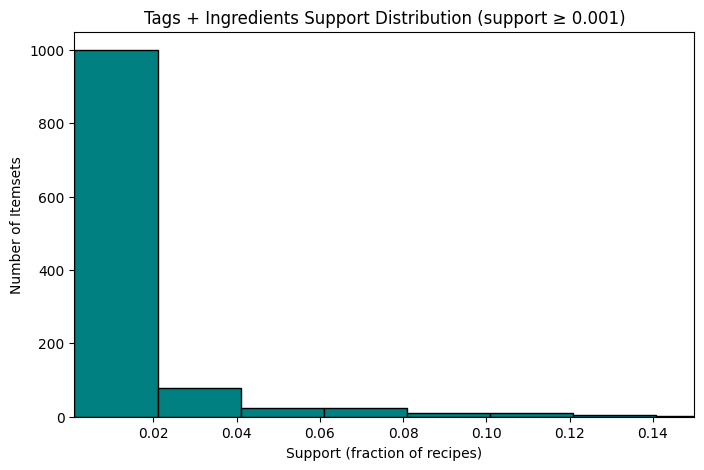

In [ ]:
from collections import Counter

# --- Step 1: Count how often each tag/ingredient appears ---
tag_ingr_counts = Counter(
    item for recipe in df_healthy["tags_ingredients"] for item in recipe
)

# --- Step 2: Convert to DataFrame ---
tag_ingr_freq = pd.DataFrame.from_dict(
    tag_ingr_counts,
    orient="index",
    columns=["count"]
)
tag_ingr_freq["support"] = tag_ingr_freq["count"] / len(df_healthy)

# --- Step 3: Filter supports >= 0.001 ---
tag_ingr_freq = tag_ingr_freq[tag_ingr_freq["support"] >= 0.001]

# --- Step 4: Sort descending by support ---
tag_ingr_freq = tag_ingr_freq.sort_values("support", ascending=False)

# --- Step 5: Show summary statistics ---
print("Support Summary for Tags + Ingredients (support ≥ 0.001):\n")
print(tag_ingr_freq["support"].describe())

# --- Step 6: Plot support distribution ---
plt.figure(figsize=(8, 5))
plt.hist(
    tag_ingr_freq["support"],
    bins=50,
    color="teal",
    edgecolor="black"
)
plt.title("Tags + Ingredients Support Distribution (support ≥ 0.001)")
plt.xlabel("Support (fraction of recipes)")
plt.ylabel("Number of Itemsets")
plt.xlim(0.001, 0.15)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pyfpgrowth

# --- Step 1: Set minimum support ---
min_support = 0.03  # based on elbow analysis
minsup_count = max(1, int(len(df_healthy) * min_support))

# --- Step 2: Find frequent patterns (tags + ingredients) ---
freq_tags_ingr = pyfpgrowth.find_frequent_patterns(
    df_healthy["tags_ingredients"].to_list(),
    minsup_count
)

print(
    f"Found {len(freq_tags_ingr)} frequent itemsets "
    f"(min_support={min_support})"
)

# --- Step 3: Generate association rules (low confidence to inspect) ---
rules_tags_ingr = pyfpgrowth.generate_association_rules(
    freq_tags_ingr,
    0.5
)

# --- Step 4: Collect confidence values ---
confidences = [conf for (_, (__, conf)) in rules_tags_ingr.items()]

# --- Step 5: Display confidence stats ---
print("\nConfidence Summary for Tags + Ingredients:")
print(pd.Series(confidences).describe())

# --- Step 6: Plot histogram of confidence values ---
plt.hist(confidences, bins=20, color="orange")
plt.title(
    "Distribution of Association Rule Confidence "
    "(Tags + Ingredients, Healthy Dataset)"
)
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.show()

Found 2810609 frequent itemsets (min_support=0.03)


### Using best parameters




In [ ]:
import pandas as pd
import pyfpgrowth

# --- Generate association rules (min_conf = 0.95) ---
healthy_tag_rules_95 = pyfpgrowth.generate_association_rules(
    freq_tags_ingr,
    0.95
)

# --- Convert to readable list ---
rules_list = []
for antecedent, (consequent, metrics) in healthy_tag_rules_95.items():
    # Handle both possible return formats
    if isinstance(metrics, tuple):
        support, confidence = metrics
    else:
        support, confidence = None, metrics

    rules_list.append((set(antecedent), set(consequent), confidence))

# --- Sort by confidence descending ---
rules_list = sorted(rules_list, key=lambda x: x[2], reverse=True)

# --- Print top 10 rules ---
print("Top 10 Association Rules (Tags + Ingredients, min_conf = 0.95):\n")

for i, (antecedent, consequent, confidence) in enumerate(
    rules_list[:10],
    start=1
):
    print(
        f"{i}. {antecedent} -> {consequent} "
        f"(confidence = {confidence:.2f})"
    )

Top 10 Association Rules (Tags + Ingredients, min_conf = 0.95):

1. {'dietary', 'vanilla'} -> {'preparation'} (confidence = 1.00)
2. {'vanilla', 'healthy'} -> {'dietary', 'preparation'} (confidence = 1.00)
3. {'preparation', 'vanilla'} -> {'dietary'} (confidence = 1.00)
4. {'dietary', 'vanilla', 'healthy'} -> {'preparation'} (confidence = 1.00)
5. {'preparation', 'vanilla', 'healthy'} -> {'dietary'} (confidence = 1.00)
6. {'time-to-make', 'vanilla'} -> {'dietary', 'preparation'} (confidence = 1.00)
7. {'time-to-make', 'vanilla', 'course'} -> {'dietary', 'preparation'} (confidence = 1.00)
8. {'dietary', 'time-to-make', 'vanilla'} -> {'preparation'} (confidence = 1.00)
9. {'preparation', 'time-to-make', 'vanilla'} -> {'dietary'} (confidence = 1.00)
10. {'dietary', 'time-to-make', 'vanilla', 'course'} -> {'preparation'} (confidence = 1.00)
